<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Sequence2Sequence%20%5BWeek%2013%5D/seq2seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Sequence-to-Sequence (Seq2Seq) Models

Welcome to this assignment! In this notebook, you will build a **Sequence-to-Sequence (Seq2Seq) model using an Encoder-Decoder architecture** from scratch. We will apply this model to a real-world task: **Machine Translation** (translating basic English sentences into Nepali).

### Learning Objectives
- Understand the motivation behind Seq2Seq models for variable-length sequence tasks.
- Implement an **Encoder** network to compress input sequences into a context vector.
- Implement a **Decoder** network to generate output sequences step-by-step.
- Understand and apply **Teacher Forcing** during training.
- Explore the differences between training and inference (e.g., Greedy Decoding vs. Beam Search).
- Train a basic neural machine translation model using PyTorch.

### Instructions
- Read the theoretical explanations carefully.
- Fill in the missing code in sections marked with `# TODO`.
- Answer the conceptual theory questions in the provided markdown cells.
- Ensure your code runs successfully from top to bottom before submission.

---
**Note:** This notebook is designed to run seamlessly on Google Colab using default libraries. No additional package installations are required.

## Part 1: Theoretical Foundations

### 1.1 The Motivation for Seq2Seq
Traditional neural networks (like CNNs or standard MLPs) require fixed-size inputs and outputs. However, in tasks like Machine Translation, Text Summarization, and Dialogue Systems, both the input sequence and the output sequence have **variable lengths**, and their lengths do not necessarily match.

For example:
- Input (English): "I am reading a book" (5 words)
- Output (Nepali): "म किताब पढ्दै छु" (4 words)

The **Seq2Seq framework** solves this by using two separate Recurrent Neural Networks (RNNs) - an Encoder and a Decoder.

### 1.2 The Encoder-Decoder Architecture
1. **The Encoder:** Reads the input sequence one token at a time and updates its hidden state. The final hidden state (often called the **context vector**) acts as a dense summary of the entire input sentence.
2. **The Decoder:** Uses this context vector as its initial hidden state and generates the output sequence one token at a time until it produces an End-Of-Sequence (`<EOS>`) token.

### 1.3 Handling Variable-Length Sequences
To process variable-length sentences in batches, we must **pad** shorter sentences with a special `<PAD>` token so that all sequences in a batch have the exact same length. We also use `<SOS>` (Start of Sequence) to tell the decoder when to begin, and `<EOS>` to tell it when to stop.

### 📝 Theory Question 1
**Question:** Why is the "context vector" often considered a bottleneck in a standard Seq2Seq model (without attention)?

**Your Answer:**
>  This phenomenon known as "fixed size bottleneck". The single, fixed-size context vector has to encode all information about the source sentence, regardless of its length. This limitation becomes more pronounced with longer sentences, as the network struggles to compress all necessary details into that fixed representation, leading to forgetting or dilution of earlier information.



## Part 2: Setup and Data Preparation

Let's start by importing the necessary PyTorch libraries and preparing our dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 2.1 The Dataset
For this assignment, we will use a small, synthetic **English-to-Nepali** dataset. While a real-world translation model requires millions of sentence pairs, this simplified dataset allows our notebook to run quickly while demonstrating the core principles.

In [2]:
# Special tokens
SOS_token = 0
EOS_token = 1
PAD_token = 2

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": SOS_token, "<EOS>": EOS_token, "<PAD>": PAD_token}
        self.word2count = {}
        self.index2word = {SOS_token: "<SOS>", EOS_token: "<EOS>", PAD_token: "<PAD>"}
        self.n_words = 3  # Count SOS, EOS, PAD

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# Toy English-Nepali Dataset
data_pairs = [
    ("I am reading a book", "म किताब पढ्दै छु"),
    ("He is eating an apple", "उ स्याउ खाँदै छ"),
    ("She goes to school", "उनी विद्यालय जान्छिन्"),
    ("They are playing football", "उनीहरू फुटबल खेल्दै छन्"),
    ("We love our country", "हामी हाम्रो देशलाई माया गर्छौं"),
    ("The sun rises in the east", "सूर्य पूर्वबाट उदाउँछ"),
    ("Water is essential for life", "पानी जीवनको लागि आवश्यक छ"),
    ("I want to learn Nepali", "म नेपाली सिक्न चाहन्छु"),
    ("This is a beautiful flower", "यो एउटा सुन्दर फूल हो"),
    ("He is my best friend", "उ मेरो मिल्ने साथी हो")
]

input_vocab = Vocabulary("English")
output_vocab = Vocabulary("Nepali")

for eng, nep in data_pairs:
    input_vocab.add_sentence(eng)
    output_vocab.add_sentence(nep)

print(f"English Vocabulary Size: {input_vocab.n_words}")
print(f"Nepali Vocabulary Size: {output_vocab.n_words}")

English Vocabulary Size: 44
Nepali Vocabulary Size: 41


### 2.2 Tokenization and Padding
Next, we convert text strings into sequences of integers based on our vocabulary. We also append the `<EOS>` token and pad the sequences so they can be grouped into batches.

In [3]:
def sentence_to_tensor(vocab, sentence, max_len):
    indexes = [vocab.word2index[word] for word in sentence.split(' ')]
    indexes.append(EOS_token)
    # Pad the sequence
    while len(indexes) < max_len:
        indexes.append(PAD_token)
    return indexes

# Find maximum sentence lengths to determine padding
max_len_eng = max([len(pair[0].split(' ')) for pair in data_pairs]) + 1 # +1 for EOS
max_len_nep = max([len(pair[1].split(' ')) for pair in data_pairs]) + 2 # +2 for SOS & EOS

input_data = []
target_data = []

for eng, nep in data_pairs:
    input_data.append(sentence_to_tensor(input_vocab, eng, max_len_eng))
    # For targets, we also prepend SOS_token
    tgt_idx = [SOS_token] + sentence_to_tensor(output_vocab, nep, max_len_nep - 1)
    target_data.append(tgt_idx)

input_tensor = torch.tensor(input_data, dtype=torch.long)
target_tensor = torch.tensor(target_data, dtype=torch.long)

# Create DataLoader
dataset = TensorDataset(input_tensor, target_tensor)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

print(f"Input tensor shape: {input_tensor.shape}")
print(f"Target tensor shape: {target_tensor.shape}")

Input tensor shape: torch.Size([10, 7])
Target tensor shape: torch.Size([10, 7])


## Part 3: The Encoder

The Encoder is an RNN (we will use a GRU - Gated Recurrent Unit) that processes the input sequence.
- It uses an **Embedding layer** to convert integer token indices into dense word vectors.
- It passes the embeddings through the **GRU**.
- We only care about the **final hidden state** to pass over to the decoder.

In [4]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # TODO: Initialize the Embedding layer
        # Hint: nn.Embedding takes (vocab_size, embedding_dim)
        self.embedding = nn.Embedding(input_size, hidden_size) # YOUR CODE HERE

        # TODO: Initialize the GRU layer
        # Hint: nn.GRU takes (input_size, hidden_size, batch_first=True)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True) # YOUR CODE HERE

    def forward(self, input_seq):
        """
        input_seq: (batch_size, sequence_length)
        """
        # TODO: Pass input_seq through the embedding layer
        embedded = self.embedding(input_seq) # YOUR CODE HERE

        # TODO: Pass the embedded tensor through the GRU
        # Note: GRU returns (output, hidden_state)
        output, hidden = self.gru(embedded) # YOUR CODE HERE

        return output, hidden

# --- DO NOT MODIFY BELOW THIS LINE ---
# Local Test
dummy_encoder = EncoderRNN(input_size=100, hidden_size=64)
if dummy_encoder.embedding is not None:
    dummy_input = torch.randint(0, 100, (2, 5)) # batch=2, seq_len=5
    out, hid = dummy_encoder(dummy_input)
    assert out.shape == (2, 5, 64), "Encoder output shape is incorrect."
    assert hid.shape == (1, 2, 64), "Encoder hidden state shape is incorrect."
    print("Encoder test passed!")

Encoder test passed!


## Part 4: The Decoder

The Decoder generates the translation step-by-step.
1. It receives the `<SOS>` token as its first input and the Encoder's final hidden state as its initial hidden state.
2. It uses an **Embedding layer**, followed by a **ReLU activation**.
3. It passes data through a **GRU**.
4. A **Linear layer** outputs predictions for the next word across the target vocabulary.

In [7]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size

        # TODO: Initialize Embedding, GRU, and Linear layers
        self.embedding = nn.Embedding(output_size, hidden_size) # output_size is vocab_size, hidden_size is embedding_dim
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)       # input_size for GRU is the embedding_dim, hidden_size is GRU's hidden_state_dim
        self.out = nn.Linear(hidden_size, output_size)       # projects hidden_size to output_size (vocab_size)
        self.relu = nn.ReLU()

    def forward(self, input_token, hidden):
        """
        input_token: (batch_size, 1) - One token at a time!
        hidden: (1, batch_size, hidden_size) - Hidden state from previous step
        """
        # TODO: Apply embedding and ReLU activation
        embedded = self.embedding(input_token) # (batch_size, 1, hidden_size)
        embedded = self.relu(embedded)

        # TODO: Pass through GRU using the hidden state
        output, hidden = self.gru(embedded, hidden) # output: (batch_size, 1, hidden_size)

        # TODO: Pass the output through the linear layer to get predictions
        # Hint: You may need to use .squeeze(1) on the output before the linear layer
        prediction = self.out(output.squeeze(1)) # (batch_size, output_size)

        return prediction, hidden

# --- DO NOT MODIFY BELOW THIS LINE ---
# Local Test
dummy_decoder = DecoderRNN(hidden_size=64, output_size=200)
if dummy_decoder.embedding is not None:
    dummy_token = torch.randint(0, 200, (2, 1))
    dummy_hidden = torch.randn(1, 2, 64)
    pred, hid = dummy_decoder(dummy_token, dummy_hidden)
    assert pred.shape == (2, 200), "Decoder prediction shape is incorrect."
    assert hid.shape == (1, 2, 64), "Decoder hidden state shape is incorrect."
    print("Decoder test passed!")

Decoder test passed!


## Part 5: Seq2Seq and Teacher Forcing

Now we combine the Encoder and Decoder. During training, the Decoder predicts the next word. However, if it makes a mistake early on, the error cascades, making training slow and unstable.

**Teacher Forcing** solves this: With a certain probability (e.g., 50%), instead of feeding the Decoder's own prediction as the input to the next time step, we supply the **actual true target word** from the training dataset. This "forces" the model back on track.

In [8]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.output_size

        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)

        # TODO: Pass the source sequence through the encoder to get the context (hidden state)
        _, hidden = self.encoder(source) # YOUR CODE HERE

        # First input to the decoder is the <SOS> token
        # Target is structured as: <SOS> word1 word2 ... <EOS> <PAD>
        decoder_input = target[:, 0].unsqueeze(1)

        # Loop through sequence from 1 to target_len (ignoring SOS token at index 0 for output mapping)
        for t in range(1, target_len):
            # TODO: Pass decoder_input and hidden state to the decoder
            output, hidden = self.decoder(decoder_input, hidden) # YOUR CODE HERE

            # Store the prediction
            outputs[:, t, :] = output

            # Get the highest predicted token index (greedy approach for this step)
            top1 = output.argmax(1)

            # TODO: Implement Teacher Forcing logic
            # 1. Determine if we should use teacher forcing by comparing a random float to teacher_forcing_ratio
            # 2. If true, set next decoder_input to the actual target token at step t
            # 3. If false, set next decoder_input to the model's prediction (top1)
            teacher_force = random.random() < teacher_forcing_ratio

            # Assign decoder_input properly based on teacher_force (ensure shape is (batch_size, 1))
            decoder_input = target[:, t].unsqueeze(1) if teacher_force else top1.unsqueeze(1)

        return outputs

### 📝 Theory Question 2
**Question:** What happens if we set `teacher_forcing_ratio = 1.0` during training, but obviously cannot use it during inference (testing)? What is this specific problem called?

**Your Answer:**
> If we set the teacher forcing ratio to 1 then instead of generalize the model starts to memorize the data. As, ratio 1 equals to 100% probability,  the decoder always receives the ground truth previous token. It never gets to experience generating a wrong token and then having to recover or correct from it. This is a critical point. But at testing there is no label to directly feed to the model which makes the garbage assumptions.
>
>This specific problem, where the model is only exposed to ground-truth sequences during training but must generate its own sequence during inference, is formally known as Exposure Bias or Mismatch between Training and Inference. It leads to compounding errors during inference because an early mistake by the decoder cannot be corrected by feeding it the true label, as would happen in full teacher forcing.



## Part 6: Training the Model

We are now ready to train our model. We will use **CrossEntropyLoss**, but we must ensure we ignore the `<PAD>` tokens so they do not affect the loss computation.

Starting Training...
Epoch [20/100], Loss: 0.0085
Epoch [40/100], Loss: 0.0031
Epoch [60/100], Loss: 0.0017
Epoch [80/100], Loss: 0.0011
Epoch [100/100], Loss: 0.0008


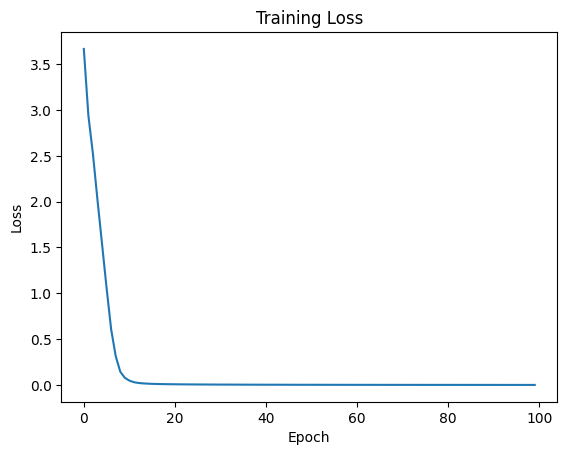

In [9]:
HIDDEN_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.005

encoder = EncoderRNN(input_size=input_vocab.n_words, hidden_size=HIDDEN_SIZE).to(device)
decoder = DecoderRNN(hidden_size=HIDDEN_SIZE, output_size=output_vocab.n_words).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# TODO: Define the criterion.
# Hint: Use nn.CrossEntropyLoss and set the ignore_index argument to PAD_token.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token) # YOUR CODE HERE

def train_model(model, dataloader, optimizer, criterion, epochs):
    model.train()
    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)

            optimizer.zero_grad()

            # Forward pass
            output = model(src, tgt, teacher_forcing_ratio=0.5)

            # Output shape: (batch_size, target_len, vocab_size)
            # Target shape: (batch_size, target_len)
            # CrossEntropyLoss expects: (batch_size * target_len, vocab_size) and (batch_size * target_len)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim) # Ignore SOS token slice
            tgt = tgt[:, 1:].reshape(-1) # Ignore SOS token slice

            loss = criterion(output, tgt)
            loss.backward()

            # Gradient clipping (optional but good practice in RNNs)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    return loss_history

# Run Training
if criterion is not None:
    print("Starting Training...")
    history = train_model(model, dataloader, optimizer, criterion, EPOCHS)

    plt.plot(history)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

## Part 7: Inference & Evaluation

During inference (translating new sentences), we do not have the target sequence to feed into the model.
Instead, we must rely completely on the model's own predictions.

### Greedy Decoding vs. Beam Search
- **Greedy Decoding:** At each time step, we simply pick the word with the highest probability and feed it as the input to the next step. (This is what we will implement).
- **Beam Search:** Explores multiple likely pathways simultaneously. Instead of just keeping the top 1 word, it keeps the top $K$ words (the "beam width"). This generally yields better translations by preventing early "greedy" mistakes.

In [10]:
def translate_sentence(model, sentence, input_vocab, output_vocab, device, max_len=20):
    model.eval()

    # Prepare input
    tokens = sentence_to_tensor(input_vocab, sentence, max_len=len(sentence.split())+1)
    src_tensor = torch.tensor([tokens]).to(device) # Add batch dimension

    with torch.no_grad():
        # TODO: Get encoder output and hidden state
        _, hidden = model.encoder(src_tensor) # YOUR CODE HERE

    # Initialize decoder input with SOS token
    decoder_input = torch.tensor([[SOS_token]]).to(device)

    decoded_words = []

    for _ in range(max_len):
        with torch.no_grad():
            # TODO: Pass through decoder
            output, hidden = model.decoder(decoder_input, hidden) # YOUR CODE HERE

        # TODO: Get the most likely word index (Greedy approach)
        top1 = output.argmax(1) # YOUR CODE HERE

        if top1.item() == EOS_token:
            break

        decoded_words.append(output_vocab.index2word[top1.item()])

        # Next input is the current prediction
        decoder_input = top1.unsqueeze(1)

    return " ".join(decoded_words)

# --- DO NOT MODIFY BELOW THIS LINE ---
# Let's test the translation on our training data to see if it memorized them correctly!
print("\n--- Translation Tests ---")
try:
    for eng, nep in data_pairs[:5]:
        translation = translate_sentence(model, eng, input_vocab, output_vocab, device)
        print(f"Input:      {eng}")
        print(f"Target:     {nep}")
        print(f"Predicted:  {translation}\n")
except TypeError:
    print("Implement the translate_sentence function to see results!")


--- Translation Tests ---
Input:      I am reading a book
Target:     म किताब पढ्दै छु
Predicted:  म किताब पढ्दै छु

Input:      He is eating an apple
Target:     उ स्याउ खाँदै छ
Predicted:  उ स्याउ खाँदै छ

Input:      She goes to school
Target:     उनी विद्यालय जान्छिन्
Predicted:  उनी विद्यालय जान्छिन्

Input:      They are playing football
Target:     उनीहरू फुटबल खेल्दै छन्
Predicted:  उनीहरू फुटबल खेल्दै छन्

Input:      We love our country
Target:     हामी हाम्रो देशलाई माया गर्छौं
Predicted:  हामी हाम्रो देशलाई माया गर्छौं



## Conclusion
Congratulations! You have successfully built a complete Sequence-to-Sequence model using PyTorch.

While this model is basic and trained on a toy dataset, the exact same architecture (often supplemented with an **Attention Mechanism**) powers production translation systems.

### Submission
Ensure all cells execute without errors and answer the markdown questions before submitting your `.ipynb` file.